In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

#### STEP1: READ DAILY SENSOR DATA

In [3]:
df= pd.read_csv("processed_data/la_daily_multivariate.csv",parse_dates=["date"])

df.set_index("date",inplace=True)
df = df.sort_index()
df.head(10)

df_la_daily = df.loc['2017':'2021']
df_la_daily_2023 = df.loc['2023']
#df_la_daily_2023.shape


/var/folders/fq/yh56gygs3bvb4gs9jzv6wdg40000gp/T/ipykernel_44141/1941129247.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df= pd.read_csv("processed_data/la_daily_multivariate.csv",parse_dates=["date"])


#### STEP2: VISUALIZATION

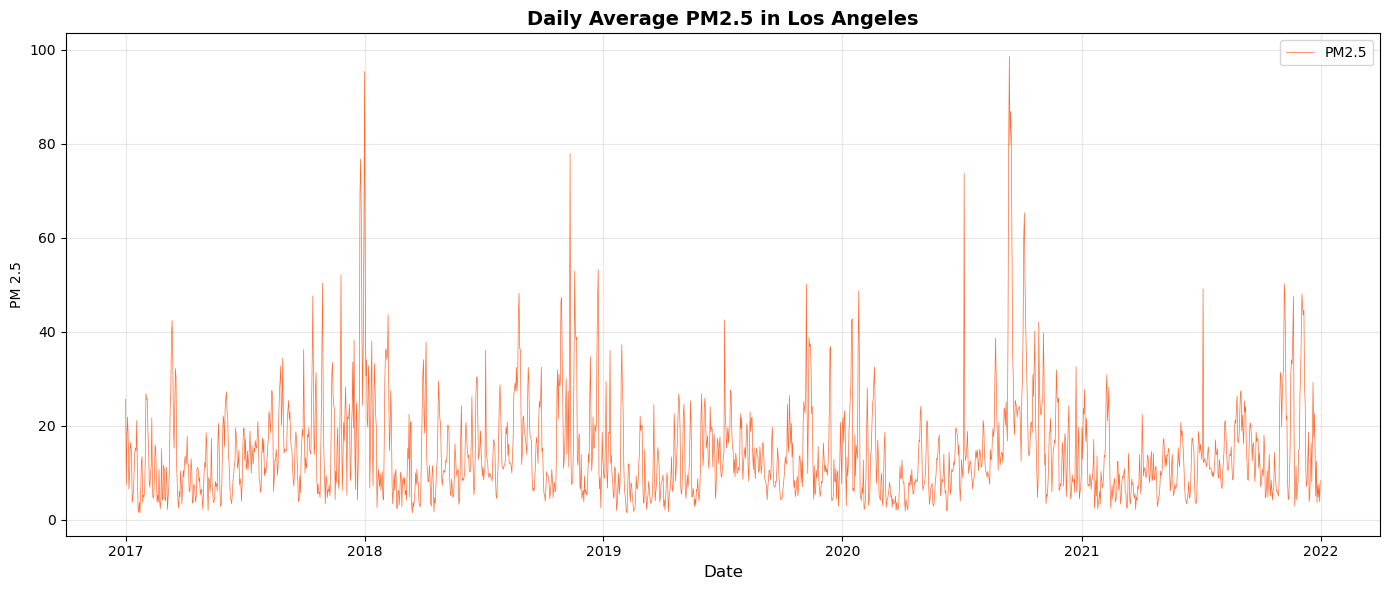

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_la_daily.index, df_la_daily['pm25_cf_1'],  color='orangered', linewidth=0.5, alpha=0.8, label='PM2.5')
ax.set_title('Daily Average PM2.5 in Los Angeles', fontsize=14, fontweight='bold')
ax.set_ylabel('PM 2.5')
ax.set_xlabel('Date',fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**We will plot monthly values for better visualization**

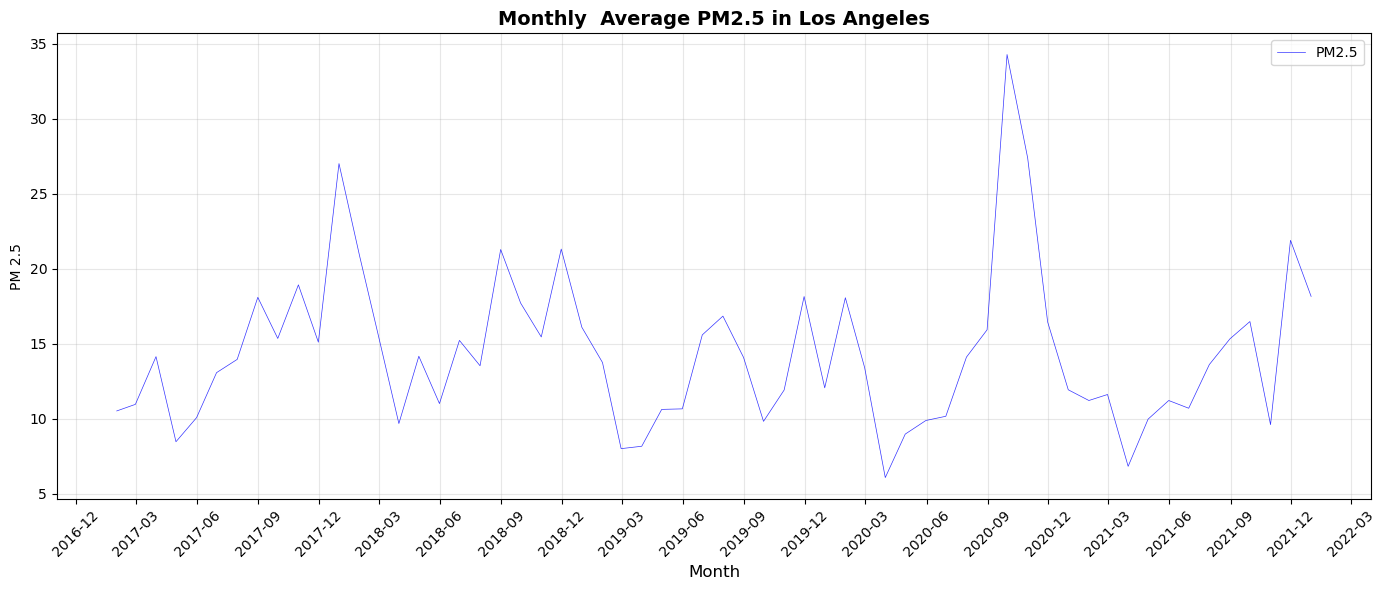

In [5]:
#Resample to monthly frequency
df_la_monthly = df_la_daily[['pm25_cf_1']].resample('ME').mean()
df_la_monthly.head()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_la_monthly.index, df_la_monthly['pm25_cf_1'],  color='blue', linewidth=0.5, alpha=0.8, label='PM2.5')
ax.set_title('Monthly  Average PM2.5 in Los Angeles', fontsize=14, fontweight='bold')
ax.set_ylabel('PM 2.5')
ax.set_xlabel('Month',fontsize=12)

# Format x-axis as Year-Month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # show every 3 months
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

There are some sudden spikes.This might be due to wild fire happened in 2017 and 2020 in LA.

Long-term trend is downward which means PM2.5 started to decrease after 2017.

#### STEP3: SEASONAL DECOMPOSITION

##### ADDITIVE DECOMPOSITION

##### First Weekly Decompostion

pm25_cf_1        0
humidity         0
pressure       342
temperature      0
dtype: int64
date
0    0.157913
1   -0.260065
2   -0.297769
3   -0.276449
4   -0.528636
5    0.373064
6    0.831942
Name: seasonal, dtype: float64

Component Statistics:
----------------------------------------------------------------------
Trend (Long-term movement):
  Mean: 14.35 µg/m³
  Min: 3.19 µg/m³, Max: 75.41 µg/m³

Seasonal (Weekly Pattern):
  Amplitude: 1.36 µg/m³
  Peak effect: 0.83 µg/m³
  Trough effect: -0.53 µg/m³

Residual (Noise/Unexplained Variation):
  Std Dev: 6.13 µg/m³


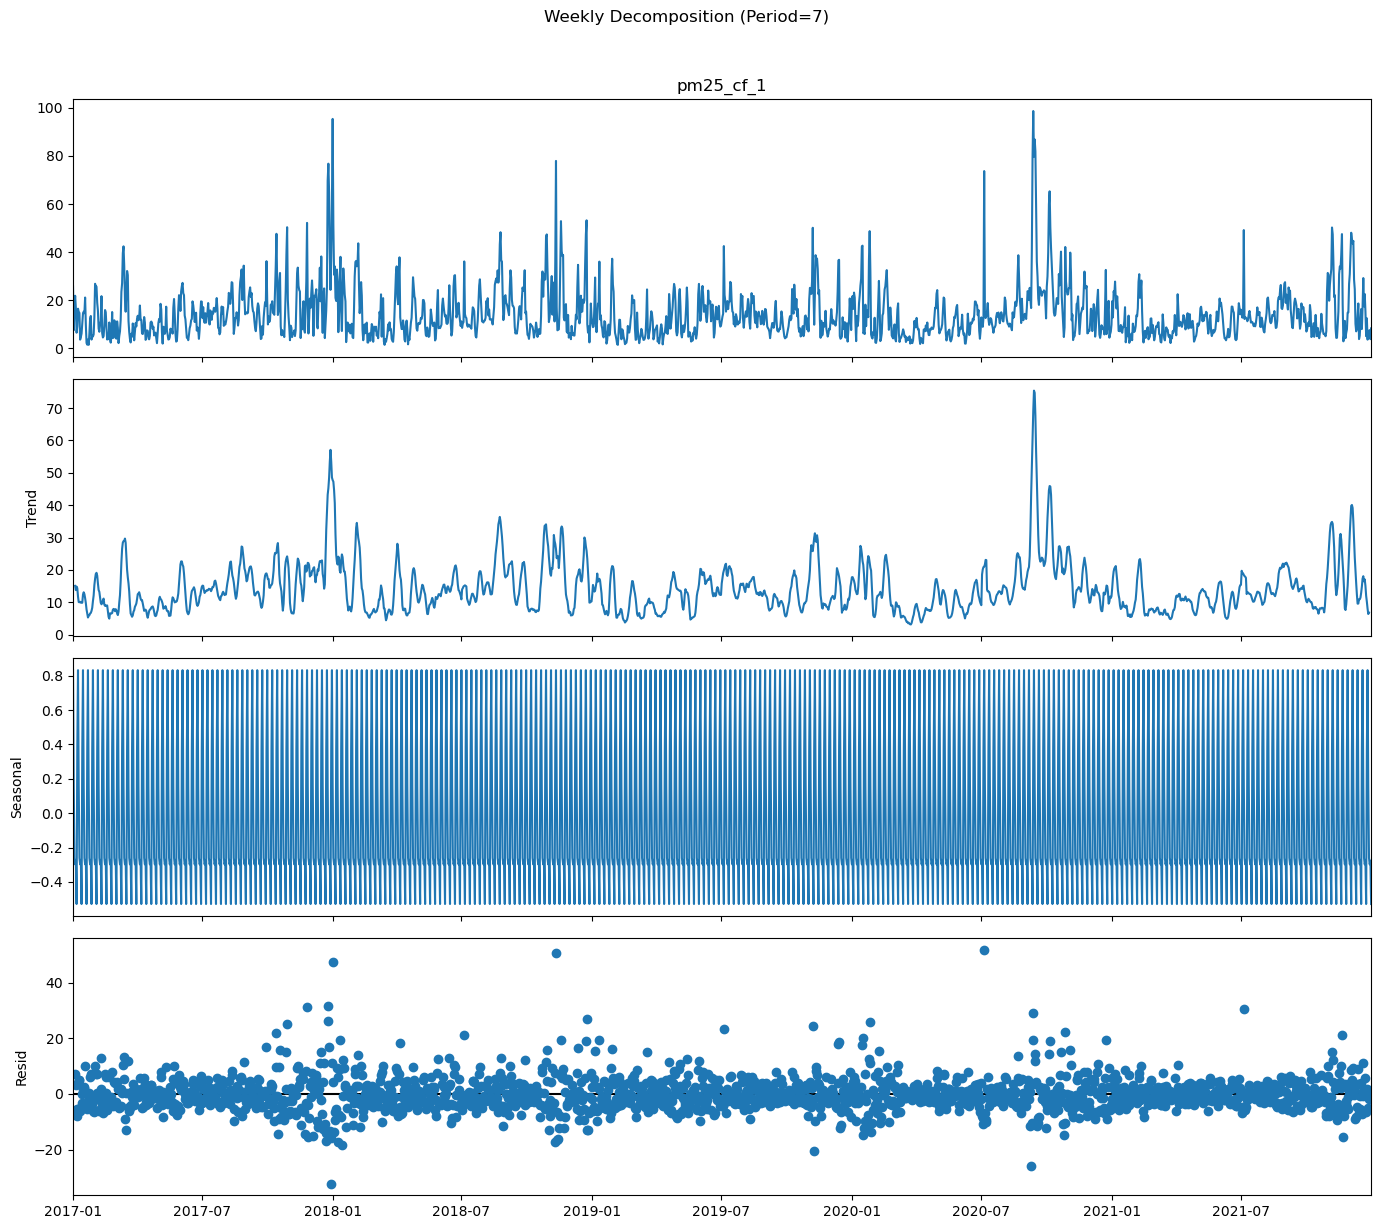

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

print(df_la_daily.isnull().sum())

# Weekly decompositon
decomp_weekly = seasonal_decompose(df_la_daily['pm25_cf_1'], model='additive', period=7)


# Extract components
trend = decomp_weekly.trend
seasonal = decomp_weekly.seasonal
residual = decomp_weekly.resid

seasonal_by_day = seasonal.groupby(seasonal.index.dayofweek).mean()
print(seasonal_by_day)

print("\nComponent Statistics:")
print("-" * 70)

print("Trend (Long-term movement):")
print(f"  Mean: {trend.mean():.2f} µg/m³")
print(f"  Min: {trend.min():.2f} µg/m³, Max: {trend.max():.2f} µg/m³")

print("\nSeasonal (Weekly Pattern):")
print(f"  Amplitude: {seasonal.max() - seasonal.min():.2f} µg/m³")
print(f"  Peak effect: {seasonal.max():.2f} µg/m³")
print(f"  Trough effect: {seasonal.min():.2f} µg/m³")

print("\nResidual (Noise/Unexplained Variation):")
print(f"  Std Dev: {residual.std():.2f} µg/m³")
# Visualize components
fig = decomp_weekly.plot()
fig.set_size_inches(14, 12)
plt.suptitle("Weekly Decomposition (Period=7)", y=1.02)
plt.tight_layout()
plt.show()

##### Yearly Decompostion


Component Statistics:
----------------------------------------------------------------------
Trend (Long-term movement):
  Mean: 14.55 µg/m³
  Min: 12.02 µg/m³, Max: 17.13 µg/m³

Seasonal (Weekly Pattern):
  Amplitude: 31.26 µg/m³
  Peak effect: 21.10 µg/m³
  Trough effect: -10.16 µg/m³

Residual (Noise/Unexplained Variation):
  Std Dev: 9.25 µg/m³


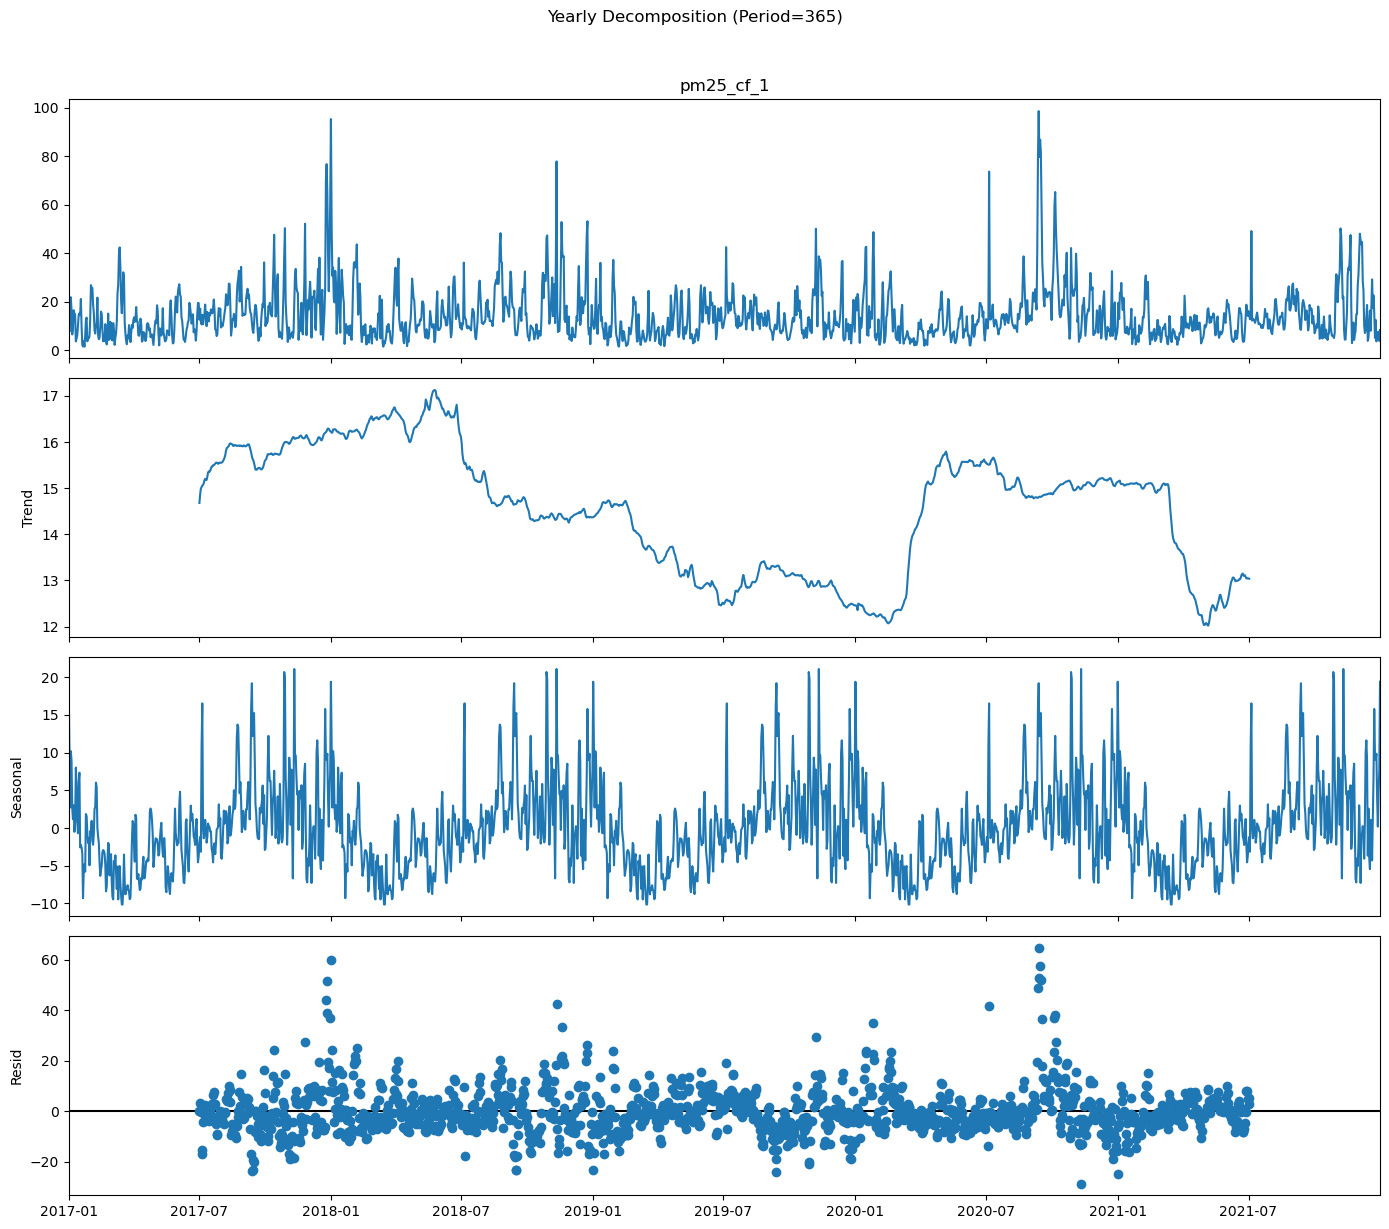

In [7]:

# Yearly decompositon
decomp_yearly = seasonal_decompose(df_la_daily['pm25_cf_1'], model='additive', period=365)


# Extract components
trend = decomp_yearly.trend
seasonal = decomp_yearly.seasonal
residual = decomp_yearly.resid


print("\nComponent Statistics:")
print("-" * 70)

print("Trend (Long-term movement):")
print(f"  Mean: {trend.mean():.2f} µg/m³")
print(f"  Min: {trend.min():.2f} µg/m³, Max: {trend.max():.2f} µg/m³")

print("\nSeasonal (Weekly Pattern):")
print(f"  Amplitude: {seasonal.max() - seasonal.min():.2f} µg/m³")
print(f"  Peak effect: {seasonal.max():.2f} µg/m³")
print(f"  Trough effect: {seasonal.min():.2f} µg/m³")

print("\nResidual (Noise/Unexplained Variation):")
print(f"  Std Dev: {residual.std():.2f} µg/m³")
# Visualize components
fig = decomp_yearly.plot()
fig.set_size_inches(14, 12)
plt.suptitle("Yearly Decomposition (Period=365)", y=1.02)
plt.tight_layout()
plt.show()

Yearly decomposition shows strong seasonal amplitude
Trend is clearly visiable.

**Check rolling mean and standart deviation for multiplicative decomposition**

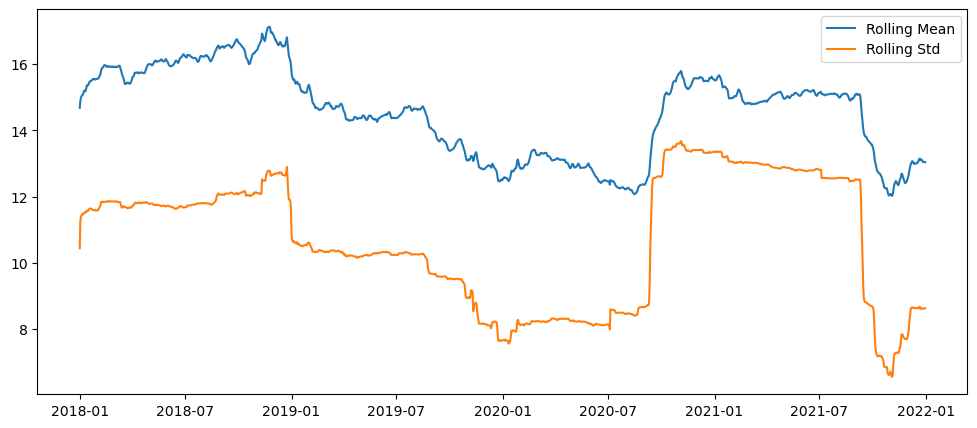

In [8]:
df_la_daily['roll_mean'] = df_la_daily['pm25_cf_1'].rolling(365).mean()
df_la_daily['roll_std']  = df_la_daily['pm25_cf_1'].rolling(365).std()

plt.figure(figsize=(12,5))
plt.plot(df_la_daily['roll_mean'], label='Rolling Mean')
plt.plot(df_la_daily['roll_std'], label='Rolling Std')
plt.legend()
plt.show()

In [13]:
df_la_daily.to_pickle("processed_data/la_daily.pkl")
df_la_daily_2023.to_pickle("processed_data/la_daily_2023.pkl")
print("Files saved successfully")

Files saved successfully
